# 06. Instrumental Variables

Instrumental variables, usually abbreviated IV, are used when treatment is endogenous: the people, customers, regions, sellers, or business units that receive treatment differ in unobserved ways that also affect the outcome.

The idea is to find a source of variation that moves treatment but is otherwise unrelated to the potential outcomes. That source of variation is the instrument. When the assumptions are credible, IV can recover a causal effect even when ordinary regression and matching are biased by unobserved selection.

IV is powerful, but it is also unforgiving. A strong statistical first stage is not enough. The instrument must have a believable design story.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why ordinary least squares can be biased when treatment selection depends on unobserved factors.
- State the core IV assumptions: relevance, independence, exclusion, and monotonicity.
- Compute the Wald estimator for a binary instrument and binary treatment.
- Explain the relationship between reduced form, first stage, and IV.
- Estimate a two-stage least squares model with controls.
- Interpret IV as a local average treatment effect for compliers.
- Diagnose weak instruments using first-stage evidence.
- Recognize why the exclusion restriction is a design argument, not just a statistical test.
- Translate an IV analysis into an industry decision readout.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from linearmodels.iv import IV2SLS

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def fit_ols(data, outcome, treatment, controls=None):
    controls = controls or []
    X = sm.add_constant(data[[treatment] + controls], has_constant="add")
    return sm.OLS(data[outcome], X).fit(cov_type="HC1")


def fit_first_stage(data, treatment, instrument, controls=None):
    controls = controls or []
    X = sm.add_constant(data[[instrument] + controls], has_constant="add")
    return sm.OLS(data[treatment], X).fit(cov_type="HC1")


def fit_reduced_form(data, outcome, instrument, controls=None):
    controls = controls or []
    X = sm.add_constant(data[[instrument] + controls], has_constant="add")
    return sm.OLS(data[outcome], X).fit(cov_type="HC1")


def coefficient_row(label, model, term):
    estimate = float(model.params[term])
    se = float(model.bse[term])
    return {
        "estimand_or_model": label,
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": float(model.pvalues[term]),
    }


def wald_estimator(data, outcome, treatment, instrument):
    means = data.groupby(instrument)[[outcome, treatment]].mean()
    reduced_form = means.loc[1, outcome] - means.loc[0, outcome]
    first_stage = means.loc[1, treatment] - means.loc[0, treatment]
    return {
        "reduced_form": float(reduced_form),
        "first_stage": float(first_stage),
        "wald_estimate": float(reduced_form / first_stage),
    }


def fit_iv2sls(data, outcome, treatment, instrument, controls=None):
    controls = controls or []
    rhs_controls = " + ".join(controls)
    if rhs_controls:
        formula = f"{outcome} ~ 1 + {rhs_controls} + [{treatment} ~ {instrument}]"
    else:
        formula = f"{outcome} ~ 1 + [{treatment} ~ {instrument}]"
    return IV2SLS.from_formula(formula, data=data).fit(cov_type="robust")


def iv_row(label, result, treatment):
    ci = result.conf_int().loc[treatment]
    return {
        "estimand_or_model": label,
        "estimate": float(result.params[treatment]),
        "std_error": float(result.std_errors[treatment]),
        "ci_low": float(ci.iloc[0]),
        "ci_high": float(ci.iloc[1]),
        "p_value": float(result.pvalues[treatment]),
    }


def plot_estimate_table(table, title, reference=None):
    plot_table = table.dropna(subset=["estimate"]).copy().reset_index(drop=True)
    y = np.arange(len(plot_table))
    lower = plot_table["estimate"] - plot_table["ci_low"]
    upper = plot_table["ci_high"] - plot_table["estimate"]

    fig, ax = plt.subplots(figsize=(9, max(3.8, 0.55 * len(plot_table) + 1.5)))
    ax.errorbar(
        plot_table["estimate"],
        y,
        xerr=[lower, upper],
        fmt="o",
        capsize=4,
        color="#2563eb",
        ecolor="#93c5fd",
    )
    if reference is not None:
        ax.axvline(reference, color="#16a34a", linestyle="--", linewidth=1.5, label="Reference")
        ax.legend()
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_table["estimand_or_model"])
    ax.invert_yaxis()
    ax.set_xlabel("Estimated effect")
    ax.set_title(title)
    return fig, ax

## 1. Where IV Fits

IV is useful when treatment selection depends on unobserved factors. Suppose high-readiness customers are more likely to adopt a new AI workflow and also more likely to renew, even without the workflow. A regression of renewal on adoption will mix the workflow effect with readiness.

An instrument creates variation in adoption that is not chosen by the customer. If the instrument changes adoption but has no direct path to renewal, the instrument isolates the causal effect for the customers whose adoption changed because of the instrument.

The modern causal interpretation of IV is closely connected to the local average treatment effect framework developed by Imbens and Angrist (1994) and Angrist, Imbens, and Rubin (1996). Angrist and Krueger (2001) emphasize that useful IV work depends on finding or creating credible sources of identifying variation, not merely on running a two-stage regression.

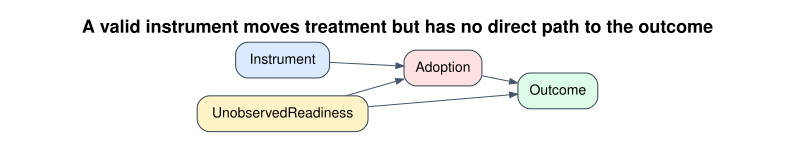

In [3]:
make_dag(
    edges=[
        ("UnobservedReadiness", "Adoption"),
        ("UnobservedReadiness", "Outcome"),
        ("Instrument", "Adoption"),
        ("Adoption", "Outcome"),
    ],
    title="A valid instrument moves treatment but has no direct path to the outcome",
    node_colors={
        "Instrument": "#dbeafe",
        "Adoption": "#fee2e2",
        "Outcome": "#dcfce7",
        "UnobservedReadiness": "#fef3c7",
    },
)

The missing arrow is the design claim. There should be no direct arrow from `Instrument` to `Outcome`, and no common cause of the instrument and outcome after conditioning on the design variables.

## 2. The Four Core Assumptions

For a binary instrument $Z$, binary treatment $D$, and outcome $Y$, IV rests on four assumptions.

**Relevance**: the instrument changes treatment.

$$
E[D_i \mid Z_i=1] - E[D_i \mid Z_i=0] \ne 0
$$

**Independence**: the instrument is as-if randomly assigned, possibly after conditioning on pre-treatment covariates.

**Exclusion**: the instrument affects the outcome only through the treatment.

**Monotonicity**: the instrument pushes treatment in one direction. There are no defiers who would take treatment when $Z=0$ but not when $Z=1$.

Under these assumptions, the Wald estimand identifies the local average treatment effect for compliers:

$$
\tau_{IV} = \frac{E[Y_i \mid Z_i=1] - E[Y_i \mid Z_i=0]}{E[D_i \mid Z_i=1] - E[D_i \mid Z_i=0]}
$$

This is a ratio of two intention-to-treat effects: the effect of the instrument on the outcome divided by the effect of the instrument on treatment.

## 3. Running Example: AI Workflow Adoption

Suppose a SaaS company wants to estimate the effect of adopting an AI-assisted renewal workflow on 90-day renewal margin. Adoption is not random. High-readiness customers are more likely to adopt and more likely to renew even without adoption.

Instrument candidate:

> Some accounts were randomly assigned to a quarter with an available implementation specialist slot. That slot increased the probability of adopting the AI workflow. The slot itself should not affect renewal margin except by causing adoption.

This is an encouragement-style instrument. The next notebook will focus on encouragement designs directly; here we use it to teach the IV mechanics.

In [4]:
def simulate_iv_data(n=8000, seed=6606, instrument_strength=1.15, exclusion_effect=0.0):
    rng = np.random.default_rng(seed)

    customer_size = rng.lognormal(mean=4.2, sigma=0.45, size=n)
    prior_usage = rng.normal(55, 12, size=n)
    churn_risk = rng.normal(0, 1, size=n)
    enterprise_probability = sigmoid(
        -0.2 + 0.45 * (customer_size - customer_size.mean()) / customer_size.std()
    )
    enterprise_plan = rng.binomial(1, enterprise_probability, size=n)

    unobserved_readiness = rng.normal(0, 1, size=n)
    specialist_slot = rng.binomial(1, 0.5, size=n)

    latent_adoption_without_slot = (
        -1.25
        + 0.018 * (prior_usage - 55)
        + 0.35 * enterprise_plan
        - 0.22 * churn_risk
        + 0.85 * unobserved_readiness
    )
    latent_adoption_with_slot = latent_adoption_without_slot + instrument_strength

    p_without_slot = sigmoid(latent_adoption_without_slot)
    p_with_slot = sigmoid(latent_adoption_with_slot)
    adoption_threshold = rng.uniform(0, 1, size=n)

    d0 = (p_without_slot > adoption_threshold).astype(int)
    d1 = (p_with_slot > adoption_threshold).astype(int)
    adopted_ai_workflow = np.where(specialist_slot == 1, d1, d0)

    principal_stratum = np.where(
        (d0 == 0) & (d1 == 0),
        "never-taker",
        np.where((d0 == 0) & (d1 == 1), "complier", "always-taker"),
    )

    true_effect = 7.5 + 2.0 * unobserved_readiness + 0.8 * enterprise_plan
    untreated_margin = (
        70
        + 0.11 * customer_size
        + 0.42 * prior_usage
        - 3.5 * churn_risk
        + 4.2 * enterprise_plan
        + 7.0 * unobserved_readiness
        + rng.normal(0, 9, size=n)
    )
    renewal_margin = untreated_margin + true_effect * adopted_ai_workflow + exclusion_effect * specialist_slot

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "renewal_margin": renewal_margin,
            "adopted_ai_workflow": adopted_ai_workflow,
            "specialist_slot": specialist_slot,
            "customer_size": customer_size,
            "prior_usage": prior_usage,
            "churn_risk": churn_risk,
            "enterprise_plan": enterprise_plan,
            "unobserved_readiness": unobserved_readiness,
            "true_effect": true_effect,
            "principal_stratum": principal_stratum,
            "d0_without_slot": d0,
            "d1_with_slot": d1,
        }
    )


df_iv = simulate_iv_data()
controls = ["customer_size", "prior_usage", "churn_risk", "enterprise_plan"]

summary = pd.DataFrame(
    {
        "value": {
            "accounts": len(df_iv),
            "share_with_specialist_slot": df_iv["specialist_slot"].mean(),
            "share_adopting_ai_workflow": df_iv["adopted_ai_workflow"].mean(),
            "avg_renewal_margin": df_iv["renewal_margin"].mean(),
            "avg_true_effect": df_iv["true_effect"].mean(),
        }
    }
)
display(summary.round(3))

,value
accounts,8000.000
share_with_specialist_slot,0.500
share_adopting_ai_workflow,0.403
avg_renewal_margin,107.011
avg_true_effect,7.909


The simulation includes an unobserved readiness variable. This variable is not available to the analyst, but it affects both adoption and renewal margin. That makes adoption endogenous.

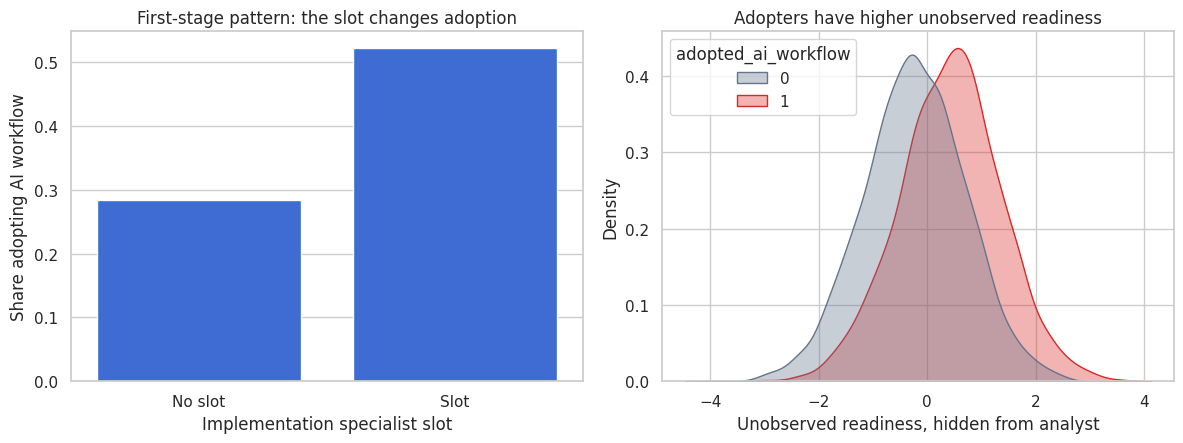

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

adoption_rates = df_iv.groupby("specialist_slot")["adopted_ai_workflow"].mean().reset_index()
sns.barplot(data=adoption_rates, x="specialist_slot", y="adopted_ai_workflow", ax=axes[0], color="#2563eb")
axes[0].set_title("First-stage pattern: the slot changes adoption")
axes[0].set_xlabel("Implementation specialist slot")
axes[0].set_ylabel("Share adopting AI workflow")
axes[0].set_xticklabels(["No slot", "Slot"])

sns.kdeplot(
    data=df_iv,
    x="unobserved_readiness",
    hue="adopted_ai_workflow",
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=axes[1],
    palette=["#64748b", "#dc2626"],
)
axes[1].set_title("Adopters have higher unobserved readiness")
axes[1].set_xlabel("Unobserved readiness, hidden from analyst")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

The left panel is the relevance story: the specialist slot moves adoption. The right panel is the endogeneity story: adopters have higher unobserved readiness, which also increases renewal margin.

## 4. Why OLS Is Biased

A regression of renewal margin on adoption compares adopters to non-adopters. But adopters are more ready, more engaged, and more likely to renew even without the AI workflow. That creates upward selection bias.

In [6]:
naive_difference = (
    df_iv.loc[df_iv["adopted_ai_workflow"] == 1, "renewal_margin"].mean()
    - df_iv.loc[df_iv["adopted_ai_workflow"] == 0, "renewal_margin"].mean()
)
ols_no_controls = fit_ols(df_iv, "renewal_margin", "adopted_ai_workflow")
ols_controls = fit_ols(df_iv, "renewal_margin", "adopted_ai_workflow", controls=controls)

ols_table = pd.DataFrame(
    [
        {
            "estimand_or_model": "Naive difference in means",
            "estimate": naive_difference,
            "std_error": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p_value": np.nan,
        },
        coefficient_row("OLS without controls", ols_no_controls, "adopted_ai_workflow"),
        coefficient_row("OLS with observed controls", ols_controls, "adopted_ai_workflow"),
    ]
)
display(ols_table.round(3))
print(f"True ATE in the simulation: {df_iv['true_effect'].mean():.2f}")
print(f"True LATE among compliers: {df_iv.loc[df_iv['principal_stratum'] == 'complier', 'true_effect'].mean():.2f}")

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,Naive difference in means,15.438,NaN,NaN,NaN,NaN
1,OLS without controls,15.438,0.317,14.816,16.060,0.000
2,OLS with observed controls,13.743,0.273,13.208,14.278,0.000


True ATE in the simulation: 7.91
True LATE among compliers: 8.18


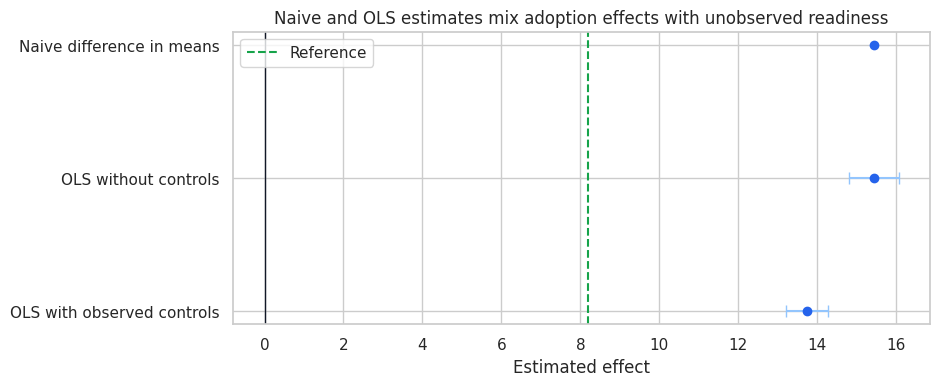

In [7]:
plot_estimate_table(
    ols_table,
    title="Naive and OLS estimates mix adoption effects with unobserved readiness",
    reference=df_iv.loc[df_iv["principal_stratum"] == "complier", "true_effect"].mean(),
)
plt.show()

Observed controls help only if they capture the source of selection. Here they do not. Unobserved readiness remains in the error term, so OLS is still biased.

## 5. Reduced Form, First Stage, and Wald Estimator

For a binary instrument, the simplest IV estimator is the Wald ratio.

The numerator is the reduced form: how much the instrument changes the outcome.

$$
RF = E[Y \mid Z=1] - E[Y \mid Z=0]
$$

The denominator is the first stage: how much the instrument changes treatment.

$$
FS = E[D \mid Z=1] - E[D \mid Z=0]
$$

The Wald estimate is:

$$
\hat{\tau}_{Wald} = \frac{RF}{FS}
$$

In [8]:
wald = wald_estimator(df_iv, "renewal_margin", "adopted_ai_workflow", "specialist_slot")
wald_table = pd.DataFrame(
    {
        "quantity": ["Reduced form", "First stage", "Wald estimate"],
        "value": [wald["reduced_form"], wald["first_stage"], wald["wald_estimate"]],
    }
)
display(wald_table.round(3))

,quantity,value
0,Reduced form,2.059
1,First stage,0.239
2,Wald estimate,8.612


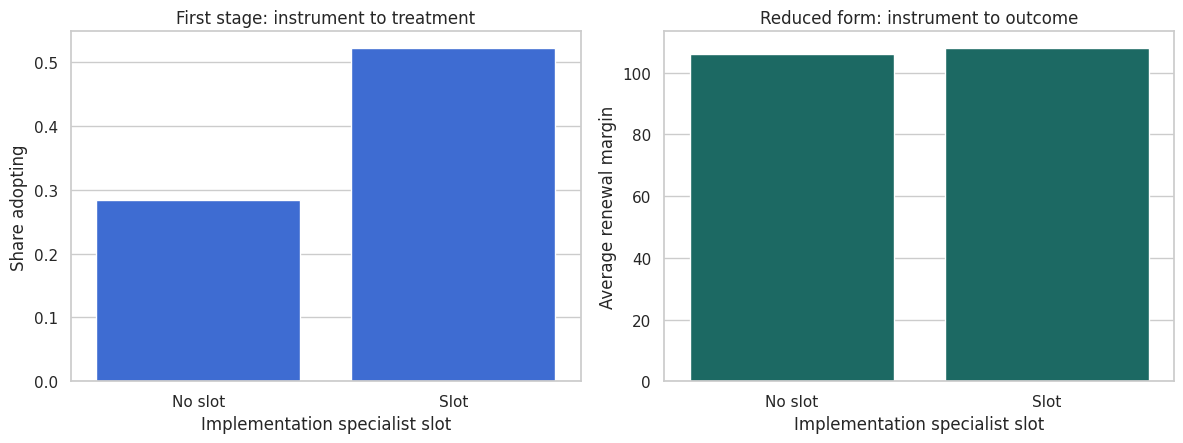

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

first_stage_means = df_iv.groupby("specialist_slot")["adopted_ai_workflow"].mean().reset_index()
sns.barplot(data=first_stage_means, x="specialist_slot", y="adopted_ai_workflow", color="#2563eb", ax=axes[0])
axes[0].set_title("First stage: instrument to treatment")
axes[0].set_xlabel("Implementation specialist slot")
axes[0].set_ylabel("Share adopting")
axes[0].set_xticklabels(["No slot", "Slot"])

reduced_form_means = df_iv.groupby("specialist_slot")["renewal_margin"].mean().reset_index()
sns.barplot(data=reduced_form_means, x="specialist_slot", y="renewal_margin", color="#0f766e", ax=axes[1])
axes[1].set_title("Reduced form: instrument to outcome")
axes[1].set_xlabel("Implementation specialist slot")
axes[1].set_ylabel("Average renewal margin")
axes[1].set_xticklabels(["No slot", "Slot"])

plt.tight_layout()
plt.show()

The reduced form is usually smaller than the treatment effect because the instrument changes treatment for only some units. IV scales the outcome movement by the treatment movement.

## 6. Two-Stage Least Squares With Controls

With covariates, the standard estimator is two-stage least squares.

First stage:

$$
D_i = \pi_0 + \pi_1Z_i + X_i'\pi_2 + v_i
$$

Second stage:

$$
Y_i = \alpha + \tau \widehat{D}_i + X_i'\beta + \epsilon_i
$$

The fitted value $\widehat{D}_i$ keeps only the part of adoption predicted by the instrument and controls. The coefficient on $\widehat{D}_i$ is the IV estimate.

The manual two-stage regression below is useful for teaching. For inference, use a proper IV estimator because naive second-stage OLS standard errors are not correct.

In [10]:
first_stage = fit_first_stage(df_iv, "adopted_ai_workflow", "specialist_slot", controls=controls)
reduced_form = fit_reduced_form(df_iv, "renewal_margin", "specialist_slot", controls=controls)

first_stage_effect = first_stage.params["specialist_slot"]
first_stage_f = float(first_stage.tvalues["specialist_slot"] ** 2)
controlled_wald = reduced_form.params["specialist_slot"] / first_stage_effect

stage_table = pd.DataFrame(
    [
        coefficient_row("First stage: slot -> adoption", first_stage, "specialist_slot"),
        coefficient_row("Reduced form: slot -> margin", reduced_form, "specialist_slot"),
    ]
)
stage_table.loc[2] = {
    "estimand_or_model": "Controlled Wald ratio",
    "estimate": controlled_wald,
    "std_error": np.nan,
    "ci_low": np.nan,
    "ci_high": np.nan,
    "p_value": np.nan,
}

display(stage_table.round(3))
print(f"First-stage robust F-statistic for specialist_slot: {first_stage_f:.1f}")

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,First stage: slot -> adoption,0.237,0.011,0.217,0.258,0.000
1,Reduced form: slot -> margin,1.876,0.299,1.290,2.462,0.000
2,Controlled Wald ratio,7.908,NaN,NaN,NaN,NaN


First-stage robust F-statistic for specialist_slot: 504.9


In [11]:
manual_work = df_iv.copy()
manual_work["predicted_adoption"] = first_stage.fittedvalues
manual_second_stage = fit_ols(
    manual_work,
    outcome="renewal_margin",
    treatment="predicted_adoption",
    controls=controls,
)

manual_table = pd.DataFrame(
    [coefficient_row("Manual 2SLS point estimate", manual_second_stage, "predicted_adoption")]
)
display(manual_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,Manual 2SLS point estimate,7.908,1.261,5.436,10.379,0.000


The manual second stage produces the same point estimate as 2SLS, but its reported standard error is not the IV standard error. The uncertainty must account for the first-stage estimation.

In [12]:
iv_result = fit_iv2sls(
    df_iv,
    outcome="renewal_margin",
    treatment="adopted_ai_workflow",
    instrument="specialist_slot",
    controls=controls,
)

iv_table = pd.DataFrame([iv_row("2SLS with robust SE", iv_result, "adopted_ai_workflow")])
display(iv_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,2SLS with robust SE,7.908,1.127,5.698,10.117,0.000


The 2SLS estimate is close to the true complier effect in this simulation. It does not estimate the average effect for every customer unless treatment effects are constant or the complier effect happens to equal the population average.

## 7. What Effect Does IV Estimate?

With heterogeneous treatment effects, IV estimates the effect for compliers: units whose treatment status changes because of the instrument. This is the local average treatment effect, or LATE (Imbens & Angrist, 1994; Angrist et al., 1996).

The principal strata are:

- Never-takers: do not adopt whether or not the specialist slot is available.
- Always-takers: adopt even without the specialist slot.
- Compliers: adopt if the specialist slot is available, otherwise do not adopt.
- Defiers: adopt only when the slot is not available. Monotonicity rules these out.

In real data, we do not observe a unit's stratum. In simulation, we can inspect it to understand the estimand.

In [13]:
strata_summary = (
    df_iv.groupby("principal_stratum")
    .agg(
        accounts=("account_id", "count"),
        share=("account_id", lambda s: len(s) / len(df_iv)),
        avg_true_effect=("true_effect", "mean"),
        avg_readiness=("unobserved_readiness", "mean"),
        adoption_rate=("adopted_ai_workflow", "mean"),
    )
    .sort_values("share", ascending=False)
)
display(strata_summary.round(3))

,accounts,share,avg_true_effect,avg_readiness,adoption_rate
principal_stratum,,,,,
never-taker,3874,0.484,7.159,-0.336,0.000
always-taker,2277,0.285,8.963,0.528,1.000
complier,1849,0.231,8.181,0.151,0.513


In [14]:
true_ate = df_iv["true_effect"].mean()
true_late = df_iv.loc[df_iv["principal_stratum"] == "complier", "true_effect"].mean()
true_att = df_iv.loc[df_iv["adopted_ai_workflow"] == 1, "true_effect"].mean()

comparison_table = pd.DataFrame(
    [
        {"estimand_or_model": "True ATE", "estimate": true_ate, "std_error": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan},
        {"estimand_or_model": "True LATE for compliers", "estimate": true_late, "std_error": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan},
        {"estimand_or_model": "True ATT among adopters", "estimate": true_att, "std_error": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan},
        coefficient_row("OLS with controls", ols_controls, "adopted_ai_workflow"),
        iv_row("2SLS with controls", iv_result, "adopted_ai_workflow"),
    ]
)
display(comparison_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,True ATE,7.909,NaN,NaN,NaN,NaN
1,True LATE for compliers,8.181,NaN,NaN,NaN,NaN
2,True ATT among adopters,8.727,NaN,NaN,NaN,NaN
3,OLS with controls,13.743,0.273,13.208,14.278,0.000
4,2SLS with controls,7.908,1.127,5.698,10.117,0.000


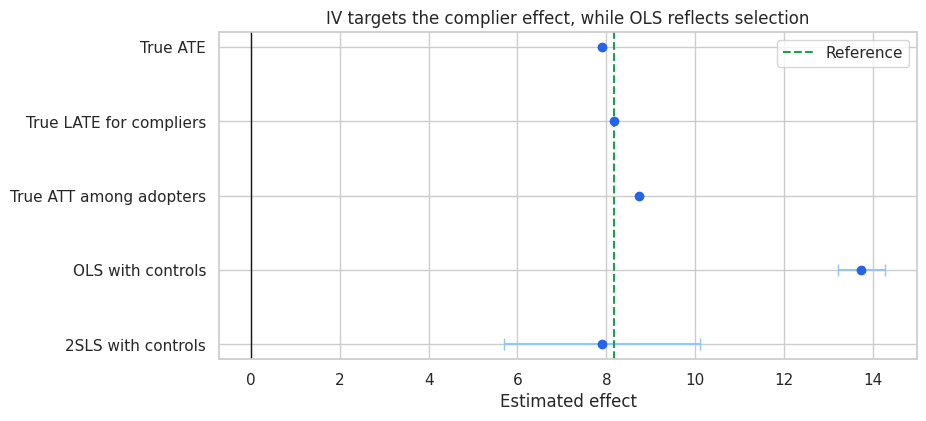

In [15]:
plot_estimate_table(
    comparison_table,
    title="IV targets the complier effect, while OLS reflects selection",
    reference=true_late,
)
plt.show()

This is the interpretability tradeoff. IV may be much more credible than OLS, but it estimates a local effect for units moved by the instrument. In business terms, the effect applies most directly to customers whose adoption can be changed by implementation capacity.

## 8. Instrument Balance Checks

If the instrument is as-if random, pre-treatment covariates should be balanced across instrument groups. Balance does not prove validity, but imbalance is a warning sign.

In [16]:
balance_rows = []
for covariate in controls:
    model = fit_reduced_form(df_iv, covariate, "specialist_slot")
    row = coefficient_row(covariate, model, "specialist_slot")
    row["mean_without_slot"] = df_iv.loc[df_iv["specialist_slot"] == 0, covariate].mean()
    row["mean_with_slot"] = df_iv.loc[df_iv["specialist_slot"] == 1, covariate].mean()
    balance_rows.append(row)

balance_table = pd.DataFrame(balance_rows)[
    ["estimand_or_model", "mean_without_slot", "mean_with_slot", "estimate", "std_error", "p_value"]
]
display(balance_table.round(3))

,estimand_or_model,mean_without_slot,mean_with_slot,estimate,std_error,p_value
0,customer_size,73.900,73.393,-0.506,0.778,0.515
1,prior_usage,54.754,55.272,0.517,0.266,0.052
2,churn_risk,0.009,0.011,0.002,0.023,0.917
3,enterprise_plan,0.454,0.456,0.002,0.011,0.874


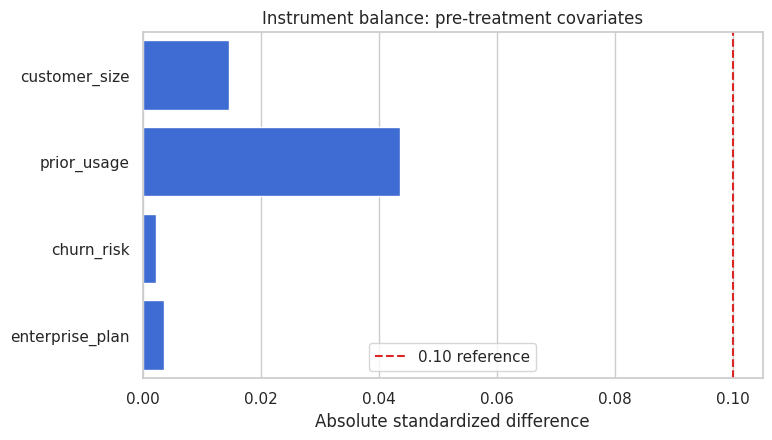

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_balance = balance_table.copy()
plot_balance["abs_standardized_difference"] = (
    plot_balance["mean_with_slot"] - plot_balance["mean_without_slot"]
).abs() / df_iv[controls].std().to_numpy()
sns.barplot(
    data=plot_balance,
    y="estimand_or_model",
    x="abs_standardized_difference",
    color="#2563eb",
    ax=ax,
)
ax.axvline(0.10, color="#dc2626", linestyle="--", linewidth=1.5, label="0.10 reference")
ax.set_title("Instrument balance: pre-treatment covariates")
ax.set_xlabel("Absolute standardized difference")
ax.set_ylabel("")
ax.legend()
plt.show()

Balance checks are about the independence assumption. They say nothing about exclusion. A perfectly randomized instrument can still violate exclusion if it changes the outcome through a path other than treatment.

## 9. Weak Instruments

A weak instrument barely changes treatment. Then the first stage is close to zero and the IV ratio becomes unstable. Staiger and Stock (1997) made weak instruments a central concern in IV practice, and later reviews emphasize that conventional IV inference can be unreliable when instruments are weak (Andrews et al., 2019).

A common first diagnostic with one endogenous variable and one instrument is the first-stage F-statistic. The old rule of thumb is that values below 10 are concerning, but modern practice is more nuanced, especially with heteroskedasticity and multiple instruments. The practical lesson is simple: a weak first stage should slow down the analysis.

In [18]:
strength_rows = []
for strength in [0.12, 0.25, 0.50, 0.80, 1.15]:
    simulated = simulate_iv_data(instrument_strength=strength, seed=6606)
    fs = fit_first_stage(simulated, "adopted_ai_workflow", "specialist_slot", controls=controls)
    iv = fit_iv2sls(simulated, "renewal_margin", "adopted_ai_workflow", "specialist_slot", controls=controls)
    row = iv_row(f"strength = {strength:.2f}", iv, "adopted_ai_workflow")
    row["instrument_strength_parameter"] = strength
    row["first_stage"] = float(fs.params["specialist_slot"])
    row["first_stage_F"] = float(fs.tvalues["specialist_slot"] ** 2)
    row["true_late"] = simulated.loc[simulated["principal_stratum"] == "complier", "true_effect"].mean()
    strength_rows.append(row)

weak_table = pd.DataFrame(strength_rows)
display(
    weak_table[
        [
            "instrument_strength_parameter",
            "first_stage",
            "first_stage_F",
            "estimate",
            "std_error",
            "ci_low",
            "ci_high",
            "true_late",
        ]
    ].round(3)
)

,instrument_strength_parameter,first_stage,first_stage_F,estimate,std_error,ci_low,ci_high,true_late
0,0.120,0.020,3.845,5.094,13.773,-21.901,32.089,8.398
1,0.250,0.043,17.774,7.031,6.216,-5.151,19.214,8.525
2,0.500,0.094,82.335,7.769,2.824,2.234,13.304,8.449
3,0.800,0.158,225.814,7.874,1.685,4.572,11.177,8.283
4,1.150,0.237,504.905,7.908,1.127,5.698,10.117,8.181


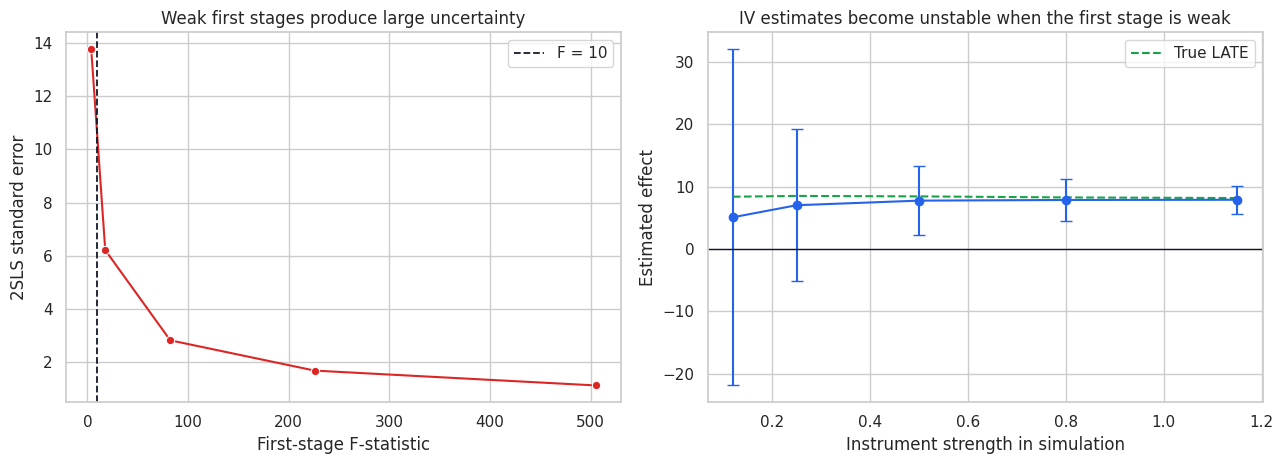

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.lineplot(
    data=weak_table,
    x="first_stage_F",
    y="std_error",
    marker="o",
    ax=axes[0],
    color="#dc2626",
)
axes[0].axvline(10, color="#111827", linestyle="--", linewidth=1.3, label="F = 10")
axes[0].set_title("Weak first stages produce large uncertainty")
axes[0].set_xlabel("First-stage F-statistic")
axes[0].set_ylabel("2SLS standard error")
axes[0].legend()

axes[1].errorbar(
    weak_table["instrument_strength_parameter"],
    weak_table["estimate"],
    yerr=1.96 * weak_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#2563eb",
)
axes[1].plot(
    weak_table["instrument_strength_parameter"],
    weak_table["true_late"],
    linestyle="--",
    color="#16a34a",
    label="True LATE",
)
axes[1].axhline(0, color="#111827", linewidth=1)
axes[1].set_title("IV estimates become unstable when the first stage is weak")
axes[1].set_xlabel("Instrument strength in simulation")
axes[1].set_ylabel("Estimated effect")
axes[1].legend()

plt.tight_layout()
plt.show()

Weak instruments are not merely a power problem. Weak IV estimates can be badly behaved, and confidence intervals can be misleading if the inference method is not robust to weak identification.

## 10. Exclusion Restriction Failure

Now suppose the implementation specialist slot has a direct effect on renewal margin that is not caused by AI workflow adoption. Perhaps the specialist gives general strategic advice, escalates support tickets, or creates goodwill even for accounts that never adopt.

That violates exclusion. The instrument still has a strong first stage, but it is no longer valid.

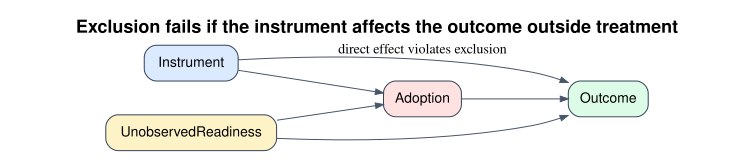

In [20]:
make_dag(
    edges=[
        ("UnobservedReadiness", "Adoption"),
        ("UnobservedReadiness", "Outcome"),
        ("Instrument", "Adoption"),
        ("Adoption", "Outcome"),
        ("Instrument", "Outcome", "direct effect violates exclusion"),
    ],
    title="Exclusion fails if the instrument affects the outcome outside treatment",
    node_colors={
        "Instrument": "#dbeafe",
        "Adoption": "#fee2e2",
        "Outcome": "#dcfce7",
        "UnobservedReadiness": "#fef3c7",
    },
)

In [21]:
valid_data = simulate_iv_data(seed=6606, exclusion_effect=0.0)
invalid_data = simulate_iv_data(seed=6606, exclusion_effect=1.50)

valid_iv = fit_iv2sls(valid_data, "renewal_margin", "adopted_ai_workflow", "specialist_slot", controls=controls)
invalid_iv = fit_iv2sls(invalid_data, "renewal_margin", "adopted_ai_workflow", "specialist_slot", controls=controls)

exclusion_table = pd.DataFrame(
    [
        {
            **iv_row("Valid exclusion", valid_iv, "adopted_ai_workflow"),
            "true_late": valid_data.loc[valid_data["principal_stratum"] == "complier", "true_effect"].mean(),
            "direct_effect_of_instrument": 0.0,
        },
        {
            **iv_row("Exclusion violation", invalid_iv, "adopted_ai_workflow"),
            "true_late": invalid_data.loc[invalid_data["principal_stratum"] == "complier", "true_effect"].mean(),
            "direct_effect_of_instrument": 1.5,
        },
    ]
)
display(exclusion_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value,true_late,direct_effect_of_instrument
0,Valid exclusion,7.908,1.127,5.698,10.117,0.000,8.181,0.000
1,Exclusion violation,14.231,1.093,12.089,16.373,0.000,8.181,1.500


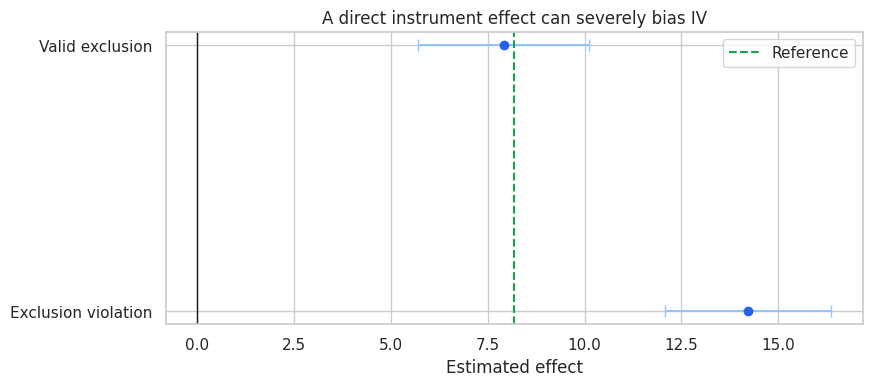

In [22]:
plot_estimate_table(
    exclusion_table,
    title="A direct instrument effect can severely bias IV",
    reference=true_late,
)
plt.show()

Even a modest direct effect can create a large IV bias because the direct reduced-form effect is divided by the first stage. This is why exclusion is usually the most contested IV assumption.

## 11. Monotonicity and Defiers

Monotonicity says the instrument moves treatment in one direction for every unit. In this example, specialist capacity can only weakly increase adoption. It does not make any customer less likely to adopt.

This assumption is often plausible for offers, reminders, eligibility, waitlist priority, distance, and capacity instruments, but it is not automatic. If the instrument causes some units to avoid treatment, the LATE interpretation becomes more fragile.

In [23]:
monotonicity_table = pd.DataFrame(
    {
        "principal_stratum": ["never-taker", "complier", "always-taker", "defier"],
        "D_if_Z_0": [0, 0, 1, 1],
        "D_if_Z_1": [0, 1, 1, 0],
        "allowed_under_monotonicity": [True, True, True, False],
        "observed_in_simulation": [
            int((df_iv["principal_stratum"] == "never-taker").sum()),
            int((df_iv["principal_stratum"] == "complier").sum()),
            int((df_iv["principal_stratum"] == "always-taker").sum()),
            0,
        ],
    }
)
display(monotonicity_table)

,principal_stratum,D_if_Z_0,D_if_Z_1,allowed_under_monotonicity,observed_in_simulation
0,never-taker,0,0,True,3874
1,complier,0,1,True,1849
2,always-taker,1,1,True,2277
3,defier,1,0,False,0


In real data, we do not observe both potential treatment states for the same unit. Monotonicity is therefore a behavioral argument. Ask whether the instrument could plausibly push some units away from the treatment.

## 12. Industry Readout Template

A strong IV readout should be organized around the identifying variation, not around the software output.

In [24]:
readout = pd.DataFrame(
    {
        "item": [
            "Decision problem",
            "Treatment",
            "Outcome",
            "Instrument",
            "First stage",
            "Reduced form",
            "2SLS estimate",
            "95% CI",
            "First-stage F-statistic",
            "Estimated population",
            "Main threat",
            "Business interpretation",
        ],
        "value": [
            "Effect of AI workflow adoption on renewal margin",
            "Customer adopted AI-assisted renewal workflow",
            "90-day renewal margin",
            "Random availability of implementation specialist slot",
            f"{first_stage_effect:.3f} increase in adoption probability",
            f"{reduced_form.params['specialist_slot']:.3f} increase in renewal margin",
            f"{iv_result.params['adopted_ai_workflow']:.3f}",
            f"[{iv_result.conf_int().loc['adopted_ai_workflow'].iloc[0]:.3f}, {iv_result.conf_int().loc['adopted_ai_workflow'].iloc[1]:.3f}]",
            f"{first_stage_f:.1f}",
            "Compliers: customers whose adoption changed because implementation capacity was available",
            "Exclusion: specialist slot must not affect renewal except through workflow adoption",
            "For capacity-movable customers, AI workflow adoption appears to increase 90-day renewal margin.",
        ],
    }
)
display(readout)

,item,value
0,Decision problem,Effect of AI workflow adoption on renewal margin
1,Treatment,Customer adopted AI-assisted renewal workflow
2,Outcome,90-day renewal margin
3,Instrument,Random availability of implementation speciali...
4,First stage,0.237 increase in adoption probability
5,Reduced form,1.876 increase in renewal margin
6,2SLS estimate,7.908
7,95% CI,"[5.698, 10.117]"
8,First-stage F-statistic,504.9
9,Estimated population,Compliers: customers whose adoption changed be...


A decision-maker should leave this readout understanding three things: what variation identified the effect, which customers the estimate applies to, and why the exclusion restriction is credible or fragile.

## Key Takeaways

- IV is designed for endogeneity from unobserved selection, measurement error, simultaneity, or reverse causality.
- A valid instrument changes treatment but affects the outcome only through treatment.
- The Wald estimator is reduced form divided by first stage.
- 2SLS is the regression version of the same idea with controls and continuous variables.
- With heterogeneous effects, IV estimates LATE for compliers, not necessarily ATE or ATT.
- First-stage strength is essential; weak instruments can make IV estimates unstable and inference unreliable.
- Exclusion is a design claim and usually the hardest assumption to defend.
- In industry, good instruments often come from randomized capacity, eligibility rules, queue priority, geographic availability, rollout constraints, or encouragements.

## References

Andrews, I., Stock, J. H., & Sun, L. (2019). Weak instruments in instrumental variables regression: Theory and practice. *Annual Review of Economics, 11*, 727-753. https://doi.org/10.1146/annurev-economics-080218-025643

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. https://doi.org/10.1080/01621459.1996.10476902

Angrist, J. D., & Krueger, A. B. (2001). Instrumental variables and the search for identification: From supply and demand to natural experiments. *Journal of Economic Perspectives, 15*(4), 69-85. https://doi.org/10.1257/jep.15.4.69

Imbens, G. W., & Angrist, J. D. (1994). Identification and estimation of local average treatment effects. *Econometrica, 62*(2), 467-475. https://doi.org/10.2307/2951620

Mourifie, I., & Wan, Y. (2017). Testing local average treatment effect assumptions. *The Review of Economics and Statistics, 99*(2), 305-313. https://doi.org/10.1162/rest_a_00622

Staiger, D. O., & Stock, J. H. (1997). Instrumental variables regression with weak instruments. *Econometrica, 65*(3), 557-586. https://doi.org/10.2307/2171753